In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\sapco\cleaned_data.csv")

print(df.head())

   order_id  order_date  customer_id product_category region  quantity  \
0     10001  2022-01-01         1102           Beauty  South         7   
1     10002  2022-01-02         1435         Clothing  South         7   
2     10003  2022-01-03         1860           Beauty   East         3   
3     10004  2022-01-04         1270      Electronics   West         5   
4     10005  2022-01-05         1106         Clothing   West         5   

   unit_price  discount payment_method  delivery_days  customer_rating  \
0      373.65      0.28         Wallet             10              4.7   
1       47.74      0.09           Card              6              3.9   
2      311.28      0.31            COD              6              2.5   
3      524.47      0.02         Wallet              6              1.6   
4      139.87      0.33         Wallet              4              4.9   

   revenue  
0  1883.20  
1   304.10  
2   644.35  
3  2569.90  
4   468.56  


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 5000
Columns: 12


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [8]:
df["order_date"] = pd.to_datetime(df["order_date"])
print(df["order_date"].dtype)

datetime64[ns]


**EDA Step 1 — Understand the dataset**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(3)
memory usage: 468.9+ KB


In [10]:
df.describe()

,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2028-11-04 12:00:00,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
min,10001.000000,2022-01-01 00:00:00,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,2025-06-03 18:00:00,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,2028-11-04 12:00:00,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,2032-04-07 06:00:00,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,2035-09-09 00:00:00,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000
std,1443.520003,NaN,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219


**EDA Step 2 — Check the data** 

In [11]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64
Duplicate rows: 0


**EDA Step 3 — Analyze sales/revenue**

In [12]:
# Total revenue
total_revenue = df["revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 5109775.74


In [13]:
# Average Revenue per Order
average_revenue = df["revenue"].mean()

print("Average Revenue per Order:", average_revenue)

Average Revenue per Order: 1021.955148


In [14]:
#Highest Revenue Order
highest_order = df.loc[df["revenue"].idxmax()]

print(highest_order)

order_id                          10810
order_date          2024-03-20 00:00:00
customer_id                        1890
product_category            Electronics
region                            South
quantity                              7
unit_price                       594.42
discount                           0.01
payment_method                     Card
delivery_days                         4
customer_rating                     4.9
revenue                         4119.33
Name: 809, dtype: object


In [15]:
# Lowest Revenue Order
lowest_order = df.loc[df["revenue"].idxmin()]

print(lowest_order)

order_id                          13644
order_date          2031-12-23 00:00:00
customer_id                        1435
product_category               Clothing
region                            South
quantity                              1
unit_price                        15.15
discount                           0.26
payment_method                     Card
delivery_days                         5
customer_rating                     3.5
revenue                           11.21
Name: 3643, dtype: object


In [16]:
import matplotlib.pyplot as plt

**EDA Step 4 — Product Category Analysis**

In [17]:
category_orders = df["product_category"].value_counts()

print(category_orders)

product_category
Electronics    1777
Clothing       1531
Home            969
Beauty          723
Name: count, dtype: int64


In [19]:
#Revenue by category
category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64


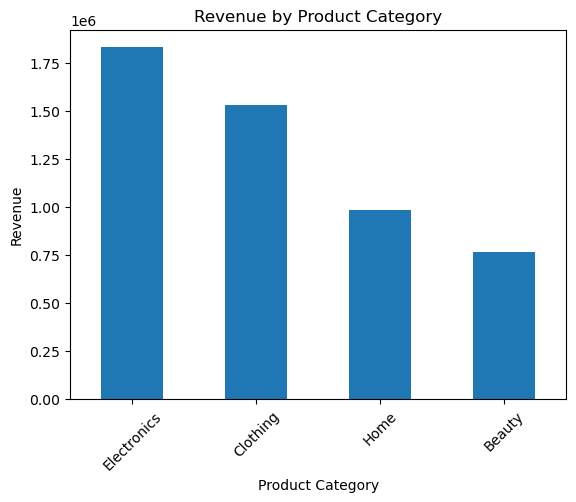

In [20]:
#chart
category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**EDA Step 5 — Regional Analysis**

In [21]:
#Revenue by region
region_revenue = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(region_revenue)

region
West     1345582.16
North    1281508.45
South    1246640.90
East     1236044.23
Name: revenue, dtype: float64


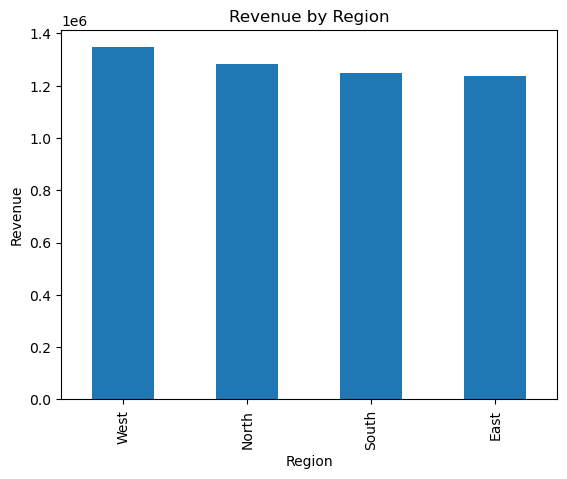

In [22]:
#chart 

region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

In [23]:
# Number of Orders by Region
region_orders = df["region"].value_counts()

print(region_orders)

region
West     1289
North    1276
East     1227
South    1208
Name: count, dtype: int64


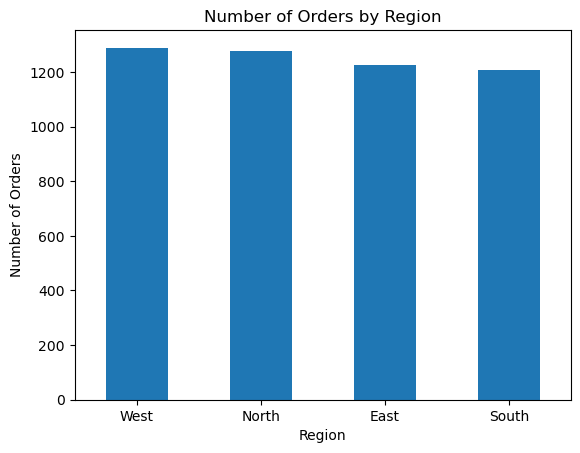

In [24]:
#chart
region_orders.plot(kind="bar")

plt.title("Number of Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

**EDA Step 6 — Payment Method Analysis**

In [25]:
payment_usage = df["payment_method"].value_counts()

print(payment_usage)

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64


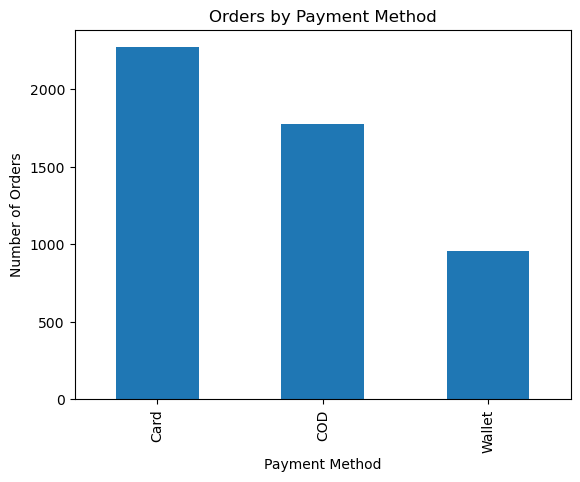

In [26]:
#chart
payment_usage.plot(kind="bar")

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.show()

**EDA Step 7 — Customer Rating Analysis**

In [27]:
# Calculate the average rating
print("Average Customer Rating:",
      df["customer_rating"].mean())

Average Customer Rating: 2.9739800000000005


In [28]:
# Rating distribution
rating_counts = df["customer_rating"].value_counts().sort_index()

print(rating_counts)

customer_rating
1.0     80
1.1    121
1.2    119
1.3    125
1.4    134
1.5    129
1.6    122
1.7    143
1.8    127
1.9    115
2.0    129
2.1    116
2.2    149
2.3    137
2.4    133
2.5    119
2.6    127
2.7    119
2.8    112
2.9    121
3.0    128
3.1    137
3.2    139
3.3    107
3.4    116
3.5    137
3.6    133
3.7    111
3.8    121
3.9    125
4.0    105
4.1    133
4.2    116
4.3    122
4.4    126
4.5    108
4.6    124
4.7    118
4.8    126
4.9    118
5.0     73
Name: count, dtype: int64


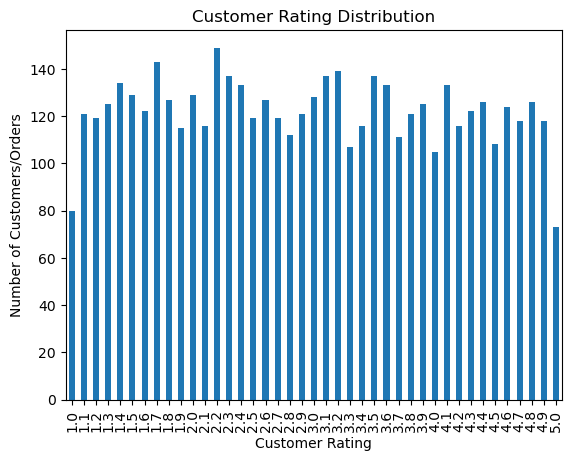

In [29]:
#chart
rating_counts.plot(kind="bar")

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Customers/Orders")
plt.show()

**EDA Step 8 — Delivery Analysis**

In [30]:
print("Average Delivery Days:",
      df["delivery_days"].mean())

print("Minimum Delivery Days:",
      df["delivery_days"].min())

print("Maximum Delivery Days:",
      df["delivery_days"].max())

Average Delivery Days: 6.1188
Minimum Delivery Days: 1
Maximum Delivery Days: 11


In [31]:
#average delivery time by region
delivery_region = (
    df.groupby("region")["delivery_days"]
    .mean()
    .sort_values(ascending=False)
)

print(delivery_region)

region
South    6.173013
North    6.118339
East     6.104319
West     6.082234
Name: delivery_days, dtype: float64


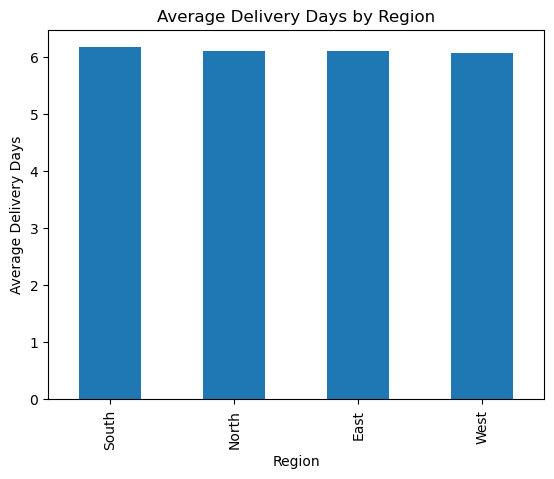

In [32]:
#chart
delivery_region.plot(kind="bar")

plt.title("Average Delivery Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Delivery Days")
plt.show()

**EDA Step 9 — Discount Analysis**

In [33]:
print("Average Discount:",
      df["discount"].mean())

print("Maximum Discount:",
      df["discount"].max())

print("Minimum Discount:",
      df["discount"].min())

Average Discount: 0.179984
Maximum Discount: 0.35
Minimum Discount: 0.0


In [ ]:
#Comaparison of discount and revenue
df["discount_group"] = pd.cut(
    df["discount"],
    bins=[0, 0.10, 0.20, 0.30, 0.40, 1],
    labels=["0-10%", "10-20%", "20-30%", "30-40%", "40%+"]
)
discount_analysis = (
    df.groupby("discount_group", observed=False)["revenue"]
    .mean()
)

print(discount_analysis)

discount_group
0-10%     1157.327862
10-20%    1057.956481
20-30%     943.936385
30-40%     841.065172
40%+              NaN
Name: revenue, dtype: float64


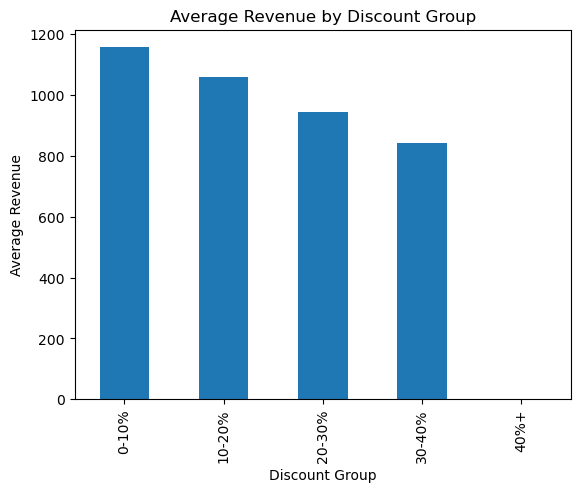

In [36]:
#chart
discount_analysis.plot(kind="bar")

plt.title("Average Revenue by Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Average Revenue")
plt.show()

**EDA Step 10 — Monthly/Time Trend**

In [37]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M")
monthly_revenue = (
    df.groupby("month")["revenue"]
    .sum()
)

print(monthly_revenue)

month
2022-01    35624.89
2022-02    29908.89
2022-03    30309.28
2022-04    30781.96
2022-05    41629.24
             ...   
2035-05    33393.87
2035-06    25205.26
2035-07    23944.48
2035-08    29354.74
2035-09     4952.23
Freq: M, Name: revenue, Length: 165, dtype: float64


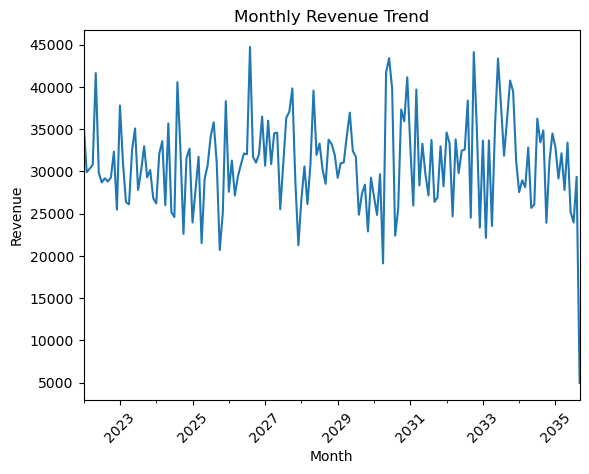

In [38]:
#create a line chart
monthly_revenue.plot(kind="line")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**EDA Step 11 — Quantity Analysis**

In [39]:
print("Total Quantity Sold:",
      df["quantity"].sum())

print("Average Quantity per Order:",
      df["quantity"].mean())

Total Quantity Sold: 20224
Average Quantity per Order: 4.0448


In [40]:
#Product category quantity
quantity_category = (
    df.groupby("product_category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(quantity_category)

product_category
Electronics    7109
Clothing       6171
Home           3949
Beauty         2995
Name: quantity, dtype: int64


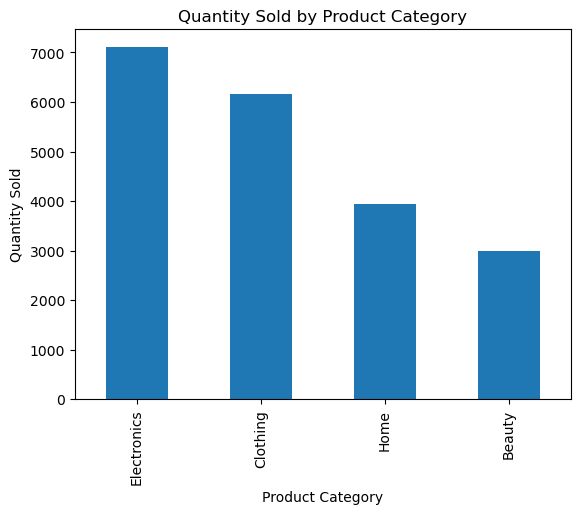

In [41]:
#chart
quantity_category.plot(kind="bar")

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.show()


**EDA Step 12 — Find anomalies**

In [46]:
Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

anomalies = df[
    (df["revenue"] < lower_limit) |
    (df["revenue"] > upper_limit)
]

print("Number of revenue anomalies:", len(anomalies))
print(anomalies)

Number of revenue anomalies: 67
      order_id order_date  customer_id product_category region  quantity  \
39       10040 2022-02-09         1474             Home  North         7   
69       10070 2022-03-11         1241           Beauty   East         7   
102      10103 2022-04-13         1201         Clothing   West         6   
126      10127 2022-05-07         1379         Clothing  South         7   
157      10158 2022-06-07         1779      Electronics  North         7   
...        ...        ...          ...              ...    ...       ...   
4498     14499 2034-04-26         1182         Clothing   West         7   
4525     14526 2034-05-23         1601         Clothing   West         7   
4728     14729 2034-12-12         1086         Clothing   East         7   
4883     14884 2035-05-16         1146      Electronics  South         7   
4980     14981 2035-08-21         1374             Home  North         7   

      unit_price  discount payment_method  delivery_day

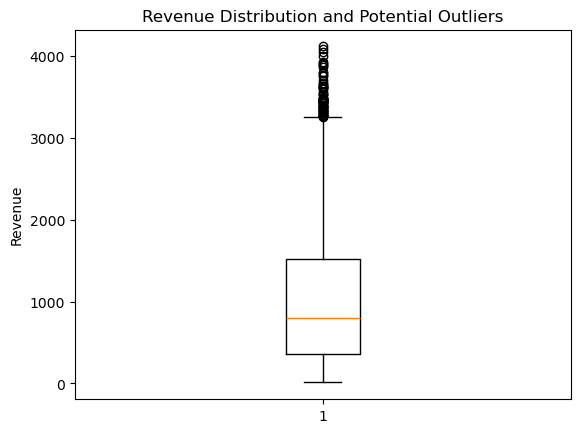

In [43]:
#visualization
plt.boxplot(df["revenue"])

plt.title("Revenue Distribution and Potential Outliers")
plt.ylabel("Revenue")
plt.show()

```python
NOTE
```Potential revenue outliers were identified for further investigation.

## Insight 1 — Product Category

The analysis shows that Category **Electronics** generated the highest total revenue, contributing significantly to overall sales.

## Insight 2 — Region

Region **West** recorded the highest revenue, while Region **East** had the lowest revenue.

## Insight 3 — Payment Method

Payment method **Cards** was the most frequently used payment method based on order count.

## Insight 4 — Delivery

Average delivery time is almost the same, but Region-**South** had the highest average delivery time (**6.17 days**), indicating a potential area for logistics investigation.

## Insight 5 — Customer Rating

The average customer rating was **2.97**.

## Insight 6 — Time Trend

Revenue showed its **highest year-over-year increase in 2026** and its **highest year-over-year decrease in 2035** during the analyzed period.

The sharp decline in 2035 may warrant further investigation to understand the factors contributing to the decrease.

## Insight 7 — Revenue Outlier Analysis

The analysis identified **67 potential revenue outliers** out of 5,000 orders using the Interquartile Range (IQR) method. These transactions have unusually high or low revenue values compared with the rest of the dataset and should be reviewed to determine whether they represent genuine high-value orders or unusual transactions.